In [2]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder
from matplotlib import pyplot
import pandas
import numpy

In [3]:
def encoder_ordinal(_df, columna, orden):
    df_enc = _df.copy()
    encoder = OrdinalEncoder(
        categories=[orden],
        handle_unknown='use_encoded_value',
        unknown_value=-1
    )

    df_enc[columna] = encoder.fit_transform(df_enc[[columna]])
    return df_enc, encoder

In [4]:
def encoder_oneHot(_df, columnas):
    encoder = OneHotEncoder(sparse_output=False)

    array_enc = encoder.fit_transform(_df[columnas])
    df_enc = _df.copy()

    df_tmp = pandas.DataFrame(
        array_enc,
        columns=encoder.get_feature_names_out(columnas),
        index=df_enc.index
    )

    df_enc = pandas.concat(
        [df_enc.drop(columns=columnas), df_tmp], 
        axis=1
    )
    return df_enc, encoder


In [5]:
def encoder_oneHot_infer(_df, _columnas, _encoder):
    array_enc = _encoder.transform(_df[_columnas])

    columnas_train = _encoder.get_feature_names_out(_columnas)

    df_tmp = pandas.DataFrame(
        array_enc,
        columns=columnas_train,
        index=_df.index
    )

    return pandas.concat([_df.drop(columns=_columnas), df_tmp], axis=1)

In [6]:
def normalizar(_df):
    df_norm = _df.copy()
    n = df_norm.shape[1]

    media = numpy.zeros(n)
    des_std = numpy.zeros(n)

    media = numpy.mean(_df, axis=0)
    des_std = numpy.std(_df, axis=0)

    df_norm = (df_norm - media) / des_std
    return df_norm, media, des_std

In [7]:
def normalizar_oneHot(_df, _mu=0, _sigma=0, bMuSigma=False):
    df_norm = _df.copy()
    media = []
    des_std = []

    if not bMuSigma:
        for columna in df_norm.columns:
            if max(df_norm[columna]) == 1 and min(df_norm[columna]) == 0:
                media.append(0)
                des_std.append(1)
                continue
            _media = numpy.mean(df_norm[columna])
            _des_std = numpy.std(df_norm[columna])
            df_norm[columna] = (df_norm[columna] - _media) / _des_std
            media.append(_media)
            des_std.append(_des_std)
    else:
        for columna in df_norm.columns:
            if max(df_norm[columna]) == 1 and min(df_norm[columna]) == 0:
                continue
            df_norm[columna] = (df_norm[columna] - _mu[columna].values[0]) / _sigma[columna].values[0]
        return df_norm

    media = pandas.DataFrame([media], columns=df_norm.columns)
    des_std = pandas.DataFrame([des_std], columns=df_norm.columns)
    return df_norm, media, des_std

In [8]:
def costo(_x, _y, _theta):
    m = _x.shape[0]
    h = numpy.dot(_x, _theta)
    J = numpy.sum( numpy.square( h - _y ) ) / (2 * m)
    return J

In [9]:
def descenso_gradiente(_x, _y, _theta, _alpha, _n_iter):
    _m = _x.shape[0]
    theta_c = _theta.copy()
    history = []
    for i in range(_n_iter):
        h = numpy.dot(_x, theta_c)
        theta_c = theta_c - _alpha / _m * numpy.dot(h - _y, _x)
        history.append( costo(_x, _y, theta_c) )
    return theta_c, history

In [11]:
dataset = pandas.read_csv('../salary_prediction_data.csv')

In [12]:
dataset.shape

(1000, 7)

In [13]:
dataset

,Education,Experience,Location,Job_Title,Age,Gender,Salary
0,High School,8,Urban,Manager,63,Male,84620.053665
1,PhD,11,Suburban,Director,59,Male,142591.255894
2,Bachelor,28,Suburban,Manager,61,Female,97800.255404
3,High School,29,Rural,Director,45,Male,96834.671282
4,PhD,25,Urban,Analyst,26,Female,132157.786175
...,...,...,...,...,...,...,...
995,High School,8,Suburban,Analyst,25,Female,64683.389864
996,High School,24,Urban,Engineer,30,Female,74468.205020
997,Master,18,Rural,Analyst,44,Male,98207.026024
998,Bachelor,27,Suburban,Director,31,Female,108544.922720


In [14]:
index_y = dataset.shape[1] - 1
X_no_enc = dataset.iloc[:, :index_y]
Y = dataset.iloc[:, index_y]

In [15]:
orden_estudio = ['High School', 'Bachelor', 'Master', 'PhD']
X, enc_estudio = encoder_ordinal(X_no_enc, 'Education', orden_estudio)
X, enc_oneHot = encoder_oneHot(X, ['Location', 'Job_Title', 'Gender'])

In [16]:
X

,Education,Experience,Age,Location_Rural,Location_Suburban,Location_Urban,Job_Title_Analyst,Job_Title_Director,Job_Title_Engineer,Job_Title_Manager,Gender_Female,Gender_Male
0,0.0,8,63,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0
1,3.0,11,59,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
2,1.0,28,61,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
3,0.0,29,45,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
4,3.0,25,26,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
995,0.0,8,25,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
996,0.0,24,30,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
997,2.0,18,44,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
998,1.0,27,31,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0


In [17]:
X_norm, mu, sigma = normalizar_oneHot(X)
X_norm

,Education,Experience,Age,Location_Rural,Location_Suburban,Location_Urban,Job_Title_Analyst,Job_Title_Director,Job_Title_Engineer,Job_Title_Manager,Gender_Female,Gender_Male
0,-1.324641,-0.812169,1.516107,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0
1,1.346006,-0.452324,1.222045,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
2,-0.434425,1.586793,1.369076,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
3,-1.324641,1.706741,0.192831,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
4,1.346006,1.226949,-1.203961,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
995,-1.324641,-0.812169,-1.277476,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
996,-1.324641,1.107001,-0.909899,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
997,0.455790,0.387312,0.119315,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
998,-0.434425,1.466845,-0.836384,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0


In [18]:
m = X_norm.shape[1]
n_iter = 10000
alpha = 0.001
theta = numpy.zeros(m)
theta, history = descenso_gradiente(X_norm, Y, theta, alpha, n_iter)
theta

array([21924.59115728,  8647.79055791,  -145.10928795, 28166.35878266,
       32103.57518356, 36957.12723907, 13703.37804341, 37516.80078657,
       17964.16969911, 28042.71267621, 48332.0753304 , 48894.9858749 ])

Text(0, 0.5, 'Costo')

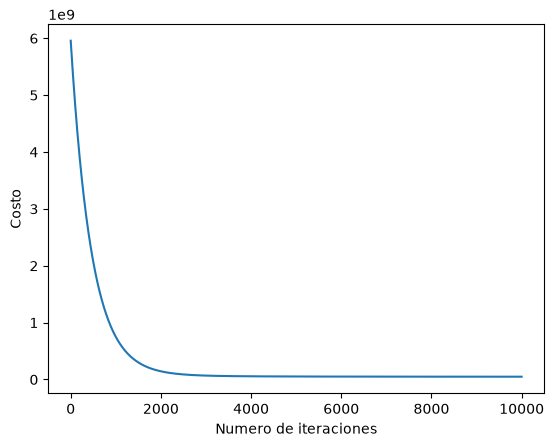

In [19]:
pyplot.plot(numpy.arange(n_iter), history)
pyplot.xlabel('Numero de iteraciones')
pyplot.ylabel('Costo')

In [20]:
persona1 = X_no_enc.iloc[0:1, :]
persona1['Education'] = 'PhD'
persona1['Experience'] = 18
persona1['Location'] = 'Suburban'
persona1['Job_Title'] = 'Director'
persona1['Age'] = 38
persona1['Gender'] = 'Male'
persona1

,Education,Experience,Location,Job_Title,Age,Gender
0,PhD,18,Suburban,Director,38,Male


In [21]:
p1, null = encoder_ordinal(persona1, 'Education', orden_estudio)
p1 = encoder_oneHot_infer(p1, ['Location', 'Job_Title', 'Gender'], enc_oneHot)
p1 = normalizar_oneHot(p1, mu, sigma, True)
p1

,Education,Experience,Age,Location_Rural,Location_Suburban,Location_Urban,Job_Title_Analyst,Job_Title_Director,Job_Title_Engineer,Job_Title_Manager,Gender_Female,Gender_Male
0,1.346006,0.387312,-0.321777,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0


In [22]:
salario = p1.dot(theta)
salario

0    151422.075348
dtype: float64